# Class Imbalance Handling

In [ ]:
# Core
import pandas as pd
import numpy as np

# Sklearn - Model & Evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import StandardScaler

# Imbalanced-learn - Resampling
from imblearn.pipeline import Pipeline          # Use this NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import RandomUnderSampler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'imblearn'

In [29]:
# read Training Data

train_preprocessed_df = pd.read_csv("../../data/preprocessed/train_preprocessed.csv") 

train_preprocessed_df.head(5)

,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age,bmi,HbA1c_level,blood_glucose_level,glucose_hba1c_interaction,...,age_bmi_interaction,bmi_hba1c_interaction,age_glucose_interaction,gender,hypertension,heart_disease,high_hba1c_flag,senior_flag,cardio_risk_flag,diabetes
0,0.0,1.0,0.0,0.0,0.0,0.361862,-0.795349,0.142857,-0.847458,-0.564644,...,-0.500569,-0.251066,-0.512287,0,0,0,0,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.261762,0.000000,0.000000,-0.847458,-0.612137,...,-0.563572,0.157075,-0.648393,0,0,0,0,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.724725,-0.682171,0.142857,-0.932203,-0.643799,...,0.118586,-0.180452,-0.073724,0,0,0,0,0,0,0
3,0.0,0.0,0.0,1.0,0.0,0.712212,0.000000,0.857143,0.000000,0.596306,...,0.324306,0.685615,0.502836,1,1,0,1,0,1,1
4,0.0,0.0,0.0,0.0,0.0,0.436937,0.000000,-1.642857,-0.237288,-0.825858,...,-0.218286,-0.855959,-0.172023,0,0,0,0,0,0,0


Graph Correlation Matrix to visualize features to remove

<Axes: >

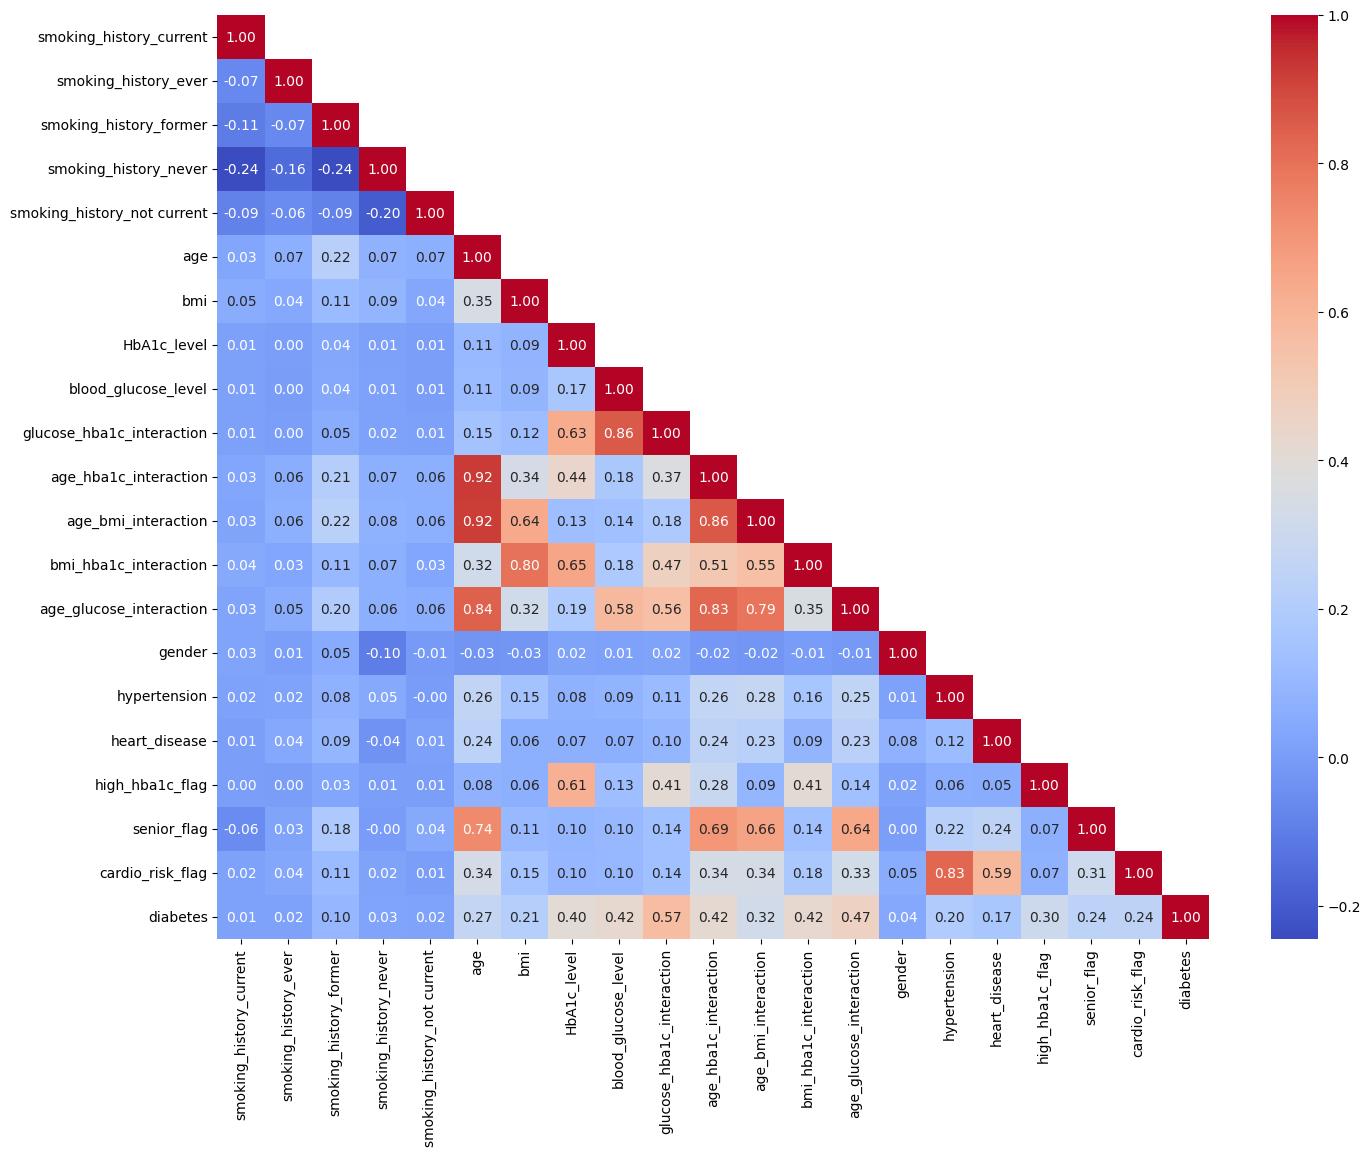

In [30]:
corr_matrix = train_preprocessed_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt=".2f")

## Feature selection

when two features have high correlation remove the one with lower correlation with target

- remove age vs keeping (age_hba1c_interaction , age_bmi_interaction and age_glucose_interaction )
- remove blood_glucose_level vs keeping (glucose_hba1c_interaction)
- remove age_bmi_interaction vs keeping (age_hba1c_interaction) 
- remove age_hba1c_interaction vs keeping ( age_glucose_interaction )
- remove hypertension vs keeping (cardio_flag_risk)

In [31]:
corr_matrix = corr_matrix.abs()  # abs() catches negative correlations too

upper_triangle = corr_matrix.where(
    mask.astype(bool)
)

to_drop = ['age', 'blood_glucose_level', 'age_bmi_interaction', 'age_hba1c_interaction', 'hypertension']

print(f"Features to drop: {to_drop}")

cleared = train_preprocessed_df.drop(columns=to_drop)
print(f"Remaining features: {cleared.columns.tolist()}")

Features to drop: ['age', 'blood_glucose_level', 'age_bmi_interaction', 'age_hba1c_interaction', 'hypertension']
Remaining features: ['smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'bmi', 'HbA1c_level', 'glucose_hba1c_interaction', 'bmi_hba1c_interaction', 'age_glucose_interaction', 'gender', 'heart_disease', 'high_hba1c_flag', 'senior_flag', 'cardio_risk_flag', 'diabetes']


In [32]:
X_train = cleared

X_test = pd.read_csv("../../data/preprocessed/validation_preprocessed.csv")

# Align test to train columns exactly
X_test = X_test[X_train.columns]


y_train = X_train['diabetes'].copy()
X_train = X_train.drop('diabetes', axis=1)

y_test = X_test['diabetes'].copy()
X_test  = X_test.drop('diabetes',axis=1 )
 

Save Class Imbalance Resolved Handled with Three Types
- SMOTE
- SMOTE TOMELINK
- SMOTE ENN
- ADASYN

In [36]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
import pandas as pd

smote = SMOTEENN(random_state=42)
smote_tomek = SMOTETomek(random_state=42)
smote_enn = SMOTEENN(random_state=42)
adasyn = ADASYN(random_state=42)

x_smote, y_smote = smote.fit_resample(X_train, y_train)
x_smote_tomek, y_smote_tomek = smote_tomek.fit_resample(X_train, y_train)
x_smote_enn, y_smote_enn = smote_enn.fit_resample(X_train, y_train)
x_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

print(pd.DataFrame(x_smote).isna().sum().sum())

pd.concat([pd.DataFrame(x_smote, columns=X_train.columns), pd.Series(y_smote, name='diabetes_target')],  axis=1).to_csv("../../data/imbalance_resolve/train_smote.csv", index=False)
pd.concat([pd.DataFrame(x_smote_tomelink, columns=X_train.columns), pd.Series(y_smote_tomelink, name='diabetes_target')],  axis=1).to_csv("../../data/imbalance_resolve/train_smote_tomek.csv", index=False)
pd.concat([pd.DataFrame(x_smote_enn, columns=X_train.columns), pd.Series(y_smote_enn, name='diabetes_target')],  axis=1).to_csv("../../data/imbalance_resolve/train_smote_enn.csv", index=False)
pd.concat([pd.DataFrame(x_adasyn, columns=X_train.columns), pd.Series(y_adasyn, name='diabetes_target')],  axis=1).to_csv("../../data/imbalance_resolve/ADASYN.csv", index=False)

0


## Try Baseline Models with Non Resolved

In [ ]:
baselines = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
}


print("Train features:", X_train.columns.tolist())
print("Test features:", X_test.columns.tolist())

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(y_test, y_proba))

Train features: ['smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'bmi', 'HbA1c_level', 'glucose_hba1c_interaction', 'bmi_hba1c_interaction', 'age_glucose_interaction', 'gender', 'heart_disease', 'high_hba1c_flag', 'senior_flag', 'cardio_risk_flag']
Test features: ['smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'bmi', 'HbA1c_level', 'glucose_hba1c_interaction', 'bmi_hba1c_interaction', 'age_glucose_interaction', 'gender', 'heart_disease', 'high_hba1c_flag', 'senior_flag', 'cardio_risk_flag']

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     13145
           1       0.44      0.90      0.59      1273

    accuracy                           0.89     14418
   macro avg       0.71      0.89      0.76     14418
weighted avg       0.94      0.89      0

### Logistic Regression

- Precision = 0.43 → flags 100 people as diabetic → only 43 actually are
- Recall    = 0.90 → out of 1,273 diabetics → catches 1,145 of them
- Overly cautious doctor sends everyone for testing, misses very few but causes a lot of unnecessary panic

### Random Forest

- Precision = 0.94 → flags 100 people as diabetic → 94 actually are
- Recall    = 0.68 → out of 1,273 diabetics → catches 866, MISSES 407
- Personality: Overconfident doctor very accurate when he says diabetic, but lets too many diabetics walk out undiagnosed

------------------------------------------

Recall

"Of everyone who ACTUALLY HAS diabetes, how many did the model catch?"

Random Forest minority recall = 0.68
→ Out of 1,273 actual diabetics in test set
→ Model caught 866 of them ✅
→ Model MISSED 407 real diabetics ❌

In [37]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

strategies = {
    'SMOTE': SMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'ADASYN': ADASYN(random_state=42)
}

results = []

for name, sampler in strategies.items():
    print(f"\nRunning {name}...")
    
    # Resample ONLY train data
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    
    # Train model
    model = RandomForestClassifier(class_weight='balanced', random_state=42)
    model.fit(X_resampled, y_resampled)
    
    # Evaluate on ORIGINAL test data (never resampled)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    
    # Store key numbers for comparison
    from sklearn.metrics import recall_score, precision_score, f1_score
    results.append({
        'Strategy': name,
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'F1': f1_score(y_test, y_pred, pos_label=1),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

# Final comparison table
results_df = pd.DataFrame(results)
print("\n===== FINAL COMPARISON =====")
print(results_df.to_string(index=False))


Running SMOTE...
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     13145
           1       0.72      0.74      0.73      1273

    accuracy                           0.95     14418
   macro avg       0.85      0.86      0.85     14418
weighted avg       0.95      0.95      0.95     14418


Running SMOTETomek...
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     13145
           1       0.71      0.74      0.73      1273

    accuracy                           0.95     14418
   macro avg       0.84      0.86      0.85     14418
weighted avg       0.95      0.95      0.95     14418


Running SMOTEENN...
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     13145
           1       0.54      0.83      0.66      1273

    accuracy                           0.92     14418
   macro avg       0.76      0.88      0.81     14418
weighted avg

In [38]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

strategies = {
    'SMOTE': SMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'ADASYN': ADASYN(random_state=42)
}

results = []

for name, sampler in strategies.items():
    print(f"\nRunning {name}...")
    
    # Resample ONLY train data
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    
    # Train model
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    model.fit(X_resampled, y_resampled)
    
    # Evaluate on ORIGINAL test data (never resampled)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    
    # Store key numbers for comparison
    from sklearn.metrics import recall_score, precision_score, f1_score
    results.append({
        'Strategy': name,
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'F1': f1_score(y_test, y_pred, pos_label=1),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

# Final comparison table
results_df = pd.DataFrame(results)
print("\n===== FINAL COMPARISON =====")
print(results_df.to_string(index=False))


Running SMOTE...
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     13145
           1       0.43      0.90      0.58      1273

    accuracy                           0.89     14418
   macro avg       0.71      0.89      0.76     14418
weighted avg       0.94      0.89      0.90     14418


Running SMOTETomek...
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     13145
           1       0.43      0.90      0.58      1273

    accuracy                           0.89     14418
   macro avg       0.71      0.89      0.76     14418
weighted avg       0.94      0.89      0.90     14418


Running SMOTEENN...
              precision    recall  f1-score   support

           0       0.99      0.87      0.93     13145
           1       0.40      0.91      0.56      1273

    accuracy                           0.87     14418
   macro avg       0.70      0.89      0.74     14418
weighted avg